In [3]:
!pip install wandb -q

Install and import libraries

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from keras.datasets import fashion_mnist
from keras.datasets import mnist

try:
    import wandb

    WANDB_READY = True
except ImportError:
    WANDB_READY = False


SEED = 42
PROJECT_NAME = "fashion-mnist-numpy-assignment"
RESULTS_DIR = Path("assignment_outputs")
RESULTS_DIR.mkdir(exist_ok=True)

np.random.seed(SEED)

Dataset labels

In [5]:
CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]


def flatten_images(images):
    images = images.astype(np.float32) / 255.0
    return images.reshape(images.shape[0], -1)


def one_hot_encode(labels, num_classes=10):
    encoded = np.zeros((labels.size, num_classes), dtype=np.float32)
    encoded[np.arange(labels.size), labels] = 1.0
    return encoded


def train_validation_split(x_data, y_data, val_ratio=0.10, seed=42):
    rng = np.random.default_rng(seed)
    indices = rng.permutation(x_data.shape[0])

    val_size = int(x_data.shape[0] * val_ratio)
    val_indices = indices[:val_size]
    train_indices = indices[val_size:]

    return (
        x_data[train_indices],
        y_data[train_indices],
        x_data[val_indices],
        y_data[val_indices],
    )


def accuracy_score(y_true, y_pred):
    return float(np.mean(y_true == y_pred))

 Loading dataset

In [6]:
(x_train_raw, y_train_full), (x_test_raw, y_test) = (
    fashion_mnist.load_data()
)

x_train_full = flatten_images(x_train_raw)
x_test = flatten_images(x_test_raw)

x_train, y_train, x_val, y_val = train_validation_split(
    x_train_full,
    y_train_full,
    val_ratio=0.10,
    seed=SEED,
)

print("Full train:", x_train_full.shape, y_train_full.shape)
print("Train:", x_train.shape, y_train.shape)
print("Validation:", x_val.shape, y_val.shape)
print("Test:", x_test.shape, y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Full train: (60000, 784) (60000,)
Train: (54000, 784) (54000,)
Validation: (6000, 784) (6000,)
Test: (10000, 784) (10000,)


Question 1

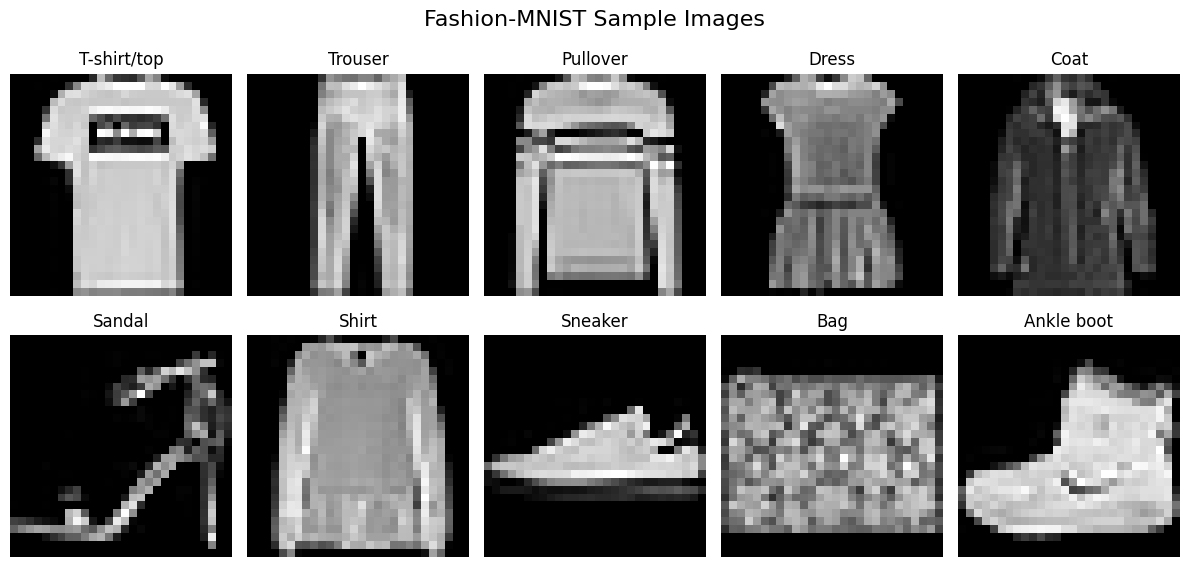

In [7]:
def plot_class_examples(images, labels, class_names):
    fig, axes = plt.subplots(2, 5, figsize=(12, 6))
    axes = axes.ravel()

    for class_id, class_name in enumerate(class_names):
        sample_index = np.where(labels == class_id)[0][0]
        axes[class_id].imshow(images[sample_index], cmap="gray")
        axes[class_id].set_title(class_name)
        axes[class_id].axis("off")

    fig.suptitle("Fashion-MNIST Sample Images", fontsize=16)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "q1_class_examples.png", dpi=150)
    plt.show()


plot_class_examples(x_train_raw, y_train_full, CLASS_NAMES)

Activation functions and loss

In [8]:
def sigmoid(z_values):
    clipped = np.clip(z_values, -500, 500)
    return 1.0 / (1.0 + np.exp(-clipped))


def softmax(logits):
    shifted_logits = logits - np.max(logits, axis=1, keepdims=True)
    exp_values = np.exp(shifted_logits)
    return exp_values / np.sum(exp_values, axis=1, keepdims=True)


def activation_forward(z_values, activation):
    if activation == "sigmoid":
        return sigmoid(z_values)

    if activation == "tanh":
        return np.tanh(z_values)

    if activation == "relu":
        return np.maximum(0.0, z_values)

    raise ValueError(f"Unknown activation function: {activation}")


def activation_backward(z_values, activated_values, activation):
    if activation == "sigmoid":
        return activated_values * (1.0 - activated_values)

    if activation == "tanh":
        return 1.0 - activated_values**2

    if activation == "relu":
        return (z_values > 0.0).astype(np.float32)

    raise ValueError(f"Unknown activation function: {activation}")


def cross_entropy_loss(probabilities, y_true, parameters, weight_decay=0.0):
    epsilon = 1e-12
    data_loss = -np.mean(
        np.sum(y_true * np.log(probabilities + epsilon), axis=1)
    )

    regularization = 0.0
    for layer in parameters:
        regularization += np.sum(layer["weights"] ** 2)

    regularization *= 0.5 * weight_decay
    return float(data_loss + regularization)


def squared_error_loss(probabilities, y_true, parameters, weight_decay=0.0):
    data_loss = 0.5 * np.mean(np.sum((probabilities - y_true) ** 2, axis=1))

    regularization = 0.0
    for layer in parameters:
        regularization += np.sum(layer["weights"] ** 2)

    regularization *= 0.5 * weight_decay
    return float(data_loss + regularization)

Question 2

FFN

In [9]:
class FeedForwardNeuralNetwork:
    def __init__(
        self,
        input_size=784,
        hidden_layers=None,
        output_size=10,
        activation="tanh",
        weight_init="xavier",
        seed=42,
    ):
        if hidden_layers is None:
            hidden_layers = [128, 128, 128, 128]

        self.input_size = input_size
        self.hidden_layers = hidden_layers
        self.output_size = output_size
        self.activation = activation
        self.weight_init = weight_init
        self.rng = np.random.default_rng(seed)

        self.layer_sizes = [input_size] + hidden_layers + [output_size]
        self.parameters = self._initialize_parameters()

    def _initialize_parameters(self):
        parameters = []

        for fan_in, fan_out in zip(self.layer_sizes[:-1], self.layer_sizes[1:]):
            if self.weight_init == "random":
                weights = self.rng.normal(
                    loc=0.0,
                    scale=0.01,
                    size=(fan_in, fan_out),
                )
            elif self.weight_init == "xavier":
                limit = np.sqrt(6.0 / (fan_in + fan_out))
                weights = self.rng.uniform(
                    low=-limit,
                    high=limit,
                    size=(fan_in, fan_out),
                )
            else:
                raise ValueError(f"Unknown initialization: {self.weight_init}")

            biases = np.zeros((1, fan_out), dtype=np.float32)

            parameters.append(
                {
                    "weights": weights.astype(np.float32),
                    "biases": biases,
                }
            )

        return parameters

    def forward(self, x_batch, parameters=None):
        if parameters is None:
            parameters = self.parameters

        activations = [x_batch]
        pre_activations = []

        current_output = x_batch

        for layer in parameters[:-1]:
            z_values = (
                current_output @ layer["weights"] + layer["biases"]
            )
            current_output = activation_forward(z_values, self.activation)

            pre_activations.append(z_values)
            activations.append(current_output)

        output_layer = parameters[-1]
        logits = current_output @ output_layer["weights"]
        logits += output_layer["biases"]

        probabilities = softmax(logits)

        pre_activations.append(logits)
        activations.append(probabilities)

        cache = {
            "activations": activations,
            "pre_activations": pre_activations,
        }

        return probabilities, cache

    def backward(
        self,
        cache,
        probabilities,
        y_true,
        parameters=None,
        loss_name="cross_entropy",
        weight_decay=0.0,
    ):
        if parameters is None:
            parameters = self.parameters

        batch_size = y_true.shape[0]
        gradients = [None] * len(parameters)

        if loss_name == "cross_entropy":
            dz = (probabilities - y_true) / batch_size
        elif loss_name == "squared_error":
            error = (probabilities - y_true) / batch_size
            correction = np.sum(error * probabilities, axis=1, keepdims=True)
            dz = probabilities * (error - correction)
        else:
            raise ValueError(f"Unknown loss function: {loss_name}")

        for layer_index in reversed(range(len(parameters))):
            previous_activation = cache["activations"][layer_index]

            dw = previous_activation.T @ dz
            db = np.sum(dz, axis=0, keepdims=True)

            dw += weight_decay * parameters[layer_index]["weights"]

            gradients[layer_index] = {
                "dw": dw,
                "db": db,
            }

            if layer_index > 0:
                da = dz @ parameters[layer_index]["weights"].T
                previous_z = cache["pre_activations"][layer_index - 1]
                previous_a = cache["activations"][layer_index]

                dz = da * activation_backward(
                    previous_z,
                    previous_a,
                    self.activation,
                )

        return gradients

    def predict_proba(self, x_data, batch_size=1024):
        probability_batches = []

        for start in range(0, x_data.shape[0], batch_size):
            end = start + batch_size
            probabilities, _ = self.forward(x_data[start:end])
            probability_batches.append(probabilities)

        return np.vstack(probability_batches)

    def predict(self, x_data, batch_size=1024):
        probabilities = self.predict_proba(x_data, batch_size=batch_size)
        return np.argmax(probabilities, axis=1)

    def evaluate(
        self,
        x_data,
        y_labels,
        loss_name="cross_entropy",
        weight_decay=0.0,
        batch_size=1024,
    ):
        y_true = one_hot_encode(y_labels, self.output_size)
        probabilities = self.predict_proba(x_data, batch_size=batch_size)

        if loss_name == "cross_entropy":
            loss = cross_entropy_loss(
                probabilities,
                y_true,
                self.parameters,
                weight_decay,
            )
        elif loss_name == "squared_error":
            loss = squared_error_loss(
                probabilities,
                y_true,
                self.parameters,
                weight_decay,
            )
        else:
            raise ValueError(f"Unknown loss function: {loss_name}")

        predictions = np.argmax(probabilities, axis=1)
        accuracy = accuracy_score(y_labels, predictions)

        return {
            "loss": loss,
            "accuracy": accuracy,
        }

In [10]:
small_model = FeedForwardNeuralNetwork(
    hidden_layers=[128, 64],
    activation="tanh",
    weight_init="xavier",
    seed=SEED,
)

sample_probabilities = small_model.predict_proba(x_train[:5])

print("Output shape:", sample_probabilities.shape)
print("Probability row sums:", np.sum(sample_probabilities, axis=1))
print(sample_probabilities)

Output shape: (5, 10)
Probability row sums: [1.0000001 1.0000001 1.        1.        1.       ]
[[0.1735402  0.10752309 0.05409519 0.14221138 0.07405233 0.10377417
  0.19867972 0.06712543 0.04661835 0.03238028]
 [0.13140212 0.11029129 0.07324124 0.09504609 0.04856873 0.07329126
  0.26152056 0.15405886 0.02462419 0.02795567]
 [0.22574154 0.08576959 0.04788613 0.13475353 0.04554268 0.10568827
  0.2649111  0.05422763 0.01792781 0.01755177]
 [0.2808157  0.06485344 0.04977556 0.09513239 0.03105777 0.11211984
  0.24643527 0.07067002 0.02661018 0.0225298 ]
 [0.15324447 0.1057196  0.06329428 0.1658959  0.0516386  0.15015617
  0.09211265 0.12571935 0.06949325 0.02272577]]


optimizers

In [11]:
def copy_parameters(parameters):
    copied = []

    for layer in parameters:
        copied.append(
            {
                "weights": layer["weights"].copy(),
                "biases": layer["biases"].copy(),
            }
        )

    return copied


def zeros_like_parameters(parameters):
    zero_values = []

    for layer in parameters:
        zero_values.append(
            {
                "weights": np.zeros_like(layer["weights"]),
                "biases": np.zeros_like(layer["biases"]),
            }
        )

    return zero_values

Question 3

In [12]:
class Optimizer:
    def lookahead(self, parameters):
        return parameters

    def update(self, parameters, gradients):
        raise NotImplementedError


class SGD(Optimizer):
    def __init__(self, learning_rate=0.001):
        self.learning_rate = learning_rate

    def update(self, parameters, gradients):
        for layer, gradient in zip(parameters, gradients):
            layer["weights"] -= self.learning_rate * gradient["dw"]
            layer["biases"] -= self.learning_rate * gradient["db"]


class Momentum(Optimizer):
    def __init__(self, parameters, learning_rate=0.001, beta=0.9):
        self.learning_rate = learning_rate
        self.beta = beta
        self.velocity = zeros_like_parameters(parameters)

    def update(self, parameters, gradients):
        for layer, gradient, velocity in zip(
            parameters,
            gradients,
            self.velocity,
        ):
            velocity["weights"] = (
                self.beta * velocity["weights"]
                + self.learning_rate * gradient["dw"]
            )
            velocity["biases"] = (
                self.beta * velocity["biases"]
                + self.learning_rate * gradient["db"]
            )

            layer["weights"] -= velocity["weights"]
            layer["biases"] -= velocity["biases"]


class Nesterov(Optimizer):
    def __init__(self, parameters, learning_rate=0.001, beta=0.9):
        self.learning_rate = learning_rate
        self.beta = beta
        self.velocity = zeros_like_parameters(parameters)

    def lookahead(self, parameters):
        future_parameters = copy_parameters(parameters)

        for layer, velocity in zip(future_parameters, self.velocity):
            layer["weights"] -= self.beta * velocity["weights"]
            layer["biases"] -= self.beta * velocity["biases"]

        return future_parameters

    def update(self, parameters, gradients):
        for layer, gradient, velocity in zip(
            parameters,
            gradients,
            self.velocity,
        ):
            velocity["weights"] = (
                self.beta * velocity["weights"]
                + self.learning_rate * gradient["dw"]
            )
            velocity["biases"] = (
                self.beta * velocity["biases"]
                + self.learning_rate * gradient["db"]
            )

            layer["weights"] -= velocity["weights"]
            layer["biases"] -= velocity["biases"]


class RMSProp(Optimizer):
    def __init__(
        self,
        parameters,
        learning_rate=0.001,
        beta=0.9,
        epsilon=1e-8,
    ):
        self.learning_rate = learning_rate
        self.beta = beta
        self.epsilon = epsilon
        self.cache = zeros_like_parameters(parameters)

    def update(self, parameters, gradients):
        for layer, gradient, cache in zip(parameters, gradients, self.cache):
            cache["weights"] = (
                self.beta * cache["weights"]
                + (1.0 - self.beta) * gradient["dw"] ** 2
            )
            cache["biases"] = (
                self.beta * cache["biases"]
                + (1.0 - self.beta) * gradient["db"] ** 2
            )

            layer["weights"] -= (
                self.learning_rate
                * gradient["dw"]
                / (np.sqrt(cache["weights"]) + self.epsilon)
            )
            layer["biases"] -= (
                self.learning_rate
                * gradient["db"]
                / (np.sqrt(cache["biases"]) + self.epsilon)
            )


class Adam(Optimizer):
    def __init__(
        self,
        parameters,
        learning_rate=0.001,
        beta1=0.9,
        beta2=0.999,
        epsilon=1e-8,
    ):
        self.learning_rate = learning_rate
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.step_count = 0

        self.first_moment = zeros_like_parameters(parameters)
        self.second_moment = zeros_like_parameters(parameters)

    def update(self, parameters, gradients):
        self.step_count += 1

        for layer, gradient, first, second in zip(
            parameters,
            gradients,
            self.first_moment,
            self.second_moment,
        ):
            first["weights"] = (
                self.beta1 * first["weights"]
                + (1.0 - self.beta1) * gradient["dw"]
            )
            first["biases"] = (
                self.beta1 * first["biases"]
                + (1.0 - self.beta1) * gradient["db"]
            )

            second["weights"] = (
                self.beta2 * second["weights"]
                + (1.0 - self.beta2) * gradient["dw"] ** 2
            )
            second["biases"] = (
                self.beta2 * second["biases"]
                + (1.0 - self.beta2) * gradient["db"] ** 2
            )

            first_w_hat = first["weights"] / (
                1.0 - self.beta1**self.step_count
            )
            first_b_hat = first["biases"] / (
                1.0 - self.beta1**self.step_count
            )

            second_w_hat = second["weights"] / (
                1.0 - self.beta2**self.step_count
            )
            second_b_hat = second["biases"] / (
                1.0 - self.beta2**self.step_count
            )

            layer["weights"] -= (
                self.learning_rate
                * first_w_hat
                / (np.sqrt(second_w_hat) + self.epsilon)
            )
            layer["biases"] -= (
                self.learning_rate
                * first_b_hat
                / (np.sqrt(second_b_hat) + self.epsilon)
            )


class Nadam(Optimizer):
    def __init__(
        self,
        parameters,
        learning_rate=0.001,
        beta1=0.9,
        beta2=0.999,
        epsilon=1e-8,
    ):
        self.learning_rate = learning_rate
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.step_count = 0

        self.first_moment = zeros_like_parameters(parameters)
        self.second_moment = zeros_like_parameters(parameters)

    def update(self, parameters, gradients):
        self.step_count += 1

        for layer, gradient, first, second in zip(
            parameters,
            gradients,
            self.first_moment,
            self.second_moment,
        ):
            first["weights"] = (
                self.beta1 * first["weights"]
                + (1.0 - self.beta1) * gradient["dw"]
            )
            first["biases"] = (
                self.beta1 * first["biases"]
                + (1.0 - self.beta1) * gradient["db"]
            )

            second["weights"] = (
                self.beta2 * second["weights"]
                + (1.0 - self.beta2) * gradient["dw"] ** 2
            )
            second["biases"] = (
                self.beta2 * second["biases"]
                + (1.0 - self.beta2) * gradient["db"] ** 2
            )

            first_w_hat = first["weights"] / (
                1.0 - self.beta1**self.step_count
            )
            first_b_hat = first["biases"] / (
                1.0 - self.beta1**self.step_count
            )

            second_w_hat = second["weights"] / (
                1.0 - self.beta2**self.step_count
            )
            second_b_hat = second["biases"] / (
                1.0 - self.beta2**self.step_count
            )

            nesterov_w = (
                self.beta1 * first_w_hat
                + (1.0 - self.beta1)
                * gradient["dw"]
                / (1.0 - self.beta1**self.step_count)
            )
            nesterov_b = (
                self.beta1 * first_b_hat
                + (1.0 - self.beta1)
                * gradient["db"]
                / (1.0 - self.beta1**self.step_count)
            )

            layer["weights"] -= (
                self.learning_rate
                * nesterov_w
                / (np.sqrt(second_w_hat) + self.epsilon)
            )
            layer["biases"] -= (
                self.learning_rate
                * nesterov_b
                / (np.sqrt(second_b_hat) + self.epsilon)
            )


def make_optimizer(name, parameters, learning_rate):
    if name == "sgd":
        return SGD(learning_rate=learning_rate)

    if name == "momentum":
        return Momentum(parameters, learning_rate=learning_rate)

    if name == "nesterov":
        return Nesterov(parameters, learning_rate=learning_rate)

    if name == "rmsprop":
        return RMSProp(parameters, learning_rate=learning_rate)

    if name == "adam":
        return Adam(parameters, learning_rate=learning_rate)

    if name == "nadam":
        return Nadam(parameters, learning_rate=learning_rate)

    raise ValueError(f"Unknown optimizer: {name}")

Mini-batch

In [13]:
def iterate_batches(x_data, y_data, batch_size, seed=42):
    rng = np.random.default_rng(seed)
    indices = rng.permutation(x_data.shape[0])

    for start in range(0, len(indices), batch_size):
        end = start + batch_size
        batch_indices = indices[start:end]

        yield x_data[batch_indices], y_data[batch_indices]


def train_model(
    model,
    optimizer,
    x_train_data,
    y_train_data,
    x_val_data=None,
    y_val_data=None,
    epochs=10,
    batch_size=64,
    loss_name="cross_entropy",
    weight_decay=0.0005,
    run=None,
    log_prefix="",
    seed=42,
):
    history = []
    best_val_accuracy = -1.0
    best_parameters = copy_parameters(model.parameters)

    for epoch in range(1, epochs + 1):
        batch_seed = seed + epoch

        for x_batch, y_batch in iterate_batches(
            x_train_data,
            y_train_data,
            batch_size,
            seed=batch_seed,
        ):
            y_batch_encoded = one_hot_encode(y_batch, model.output_size)

            working_parameters = optimizer.lookahead(model.parameters)
            probabilities, cache = model.forward(
                x_batch,
                parameters=working_parameters,
            )

            gradients = model.backward(
                cache=cache,
                probabilities=probabilities,
                y_true=y_batch_encoded,
                parameters=working_parameters,
                loss_name=loss_name,
                weight_decay=weight_decay,
            )

            optimizer.update(model.parameters, gradients)

        train_metrics = model.evaluate(
            x_train_data,
            y_train_data,
            loss_name=loss_name,
            weight_decay=weight_decay,
        )

        row = {
            "epoch": epoch,
            f"{log_prefix}train_loss": train_metrics["loss"],
            f"{log_prefix}train_acc": train_metrics["accuracy"],
        }

        if x_val_data is not None and y_val_data is not None:
            val_metrics = model.evaluate(
                x_val_data,
                y_val_data,
                loss_name=loss_name,
                weight_decay=weight_decay,
            )

            row[f"{log_prefix}val_loss"] = val_metrics["loss"]
            row[f"{log_prefix}val_acc"] = val_metrics["accuracy"]

            if val_metrics["accuracy"] > best_val_accuracy:
                best_val_accuracy = val_metrics["accuracy"]
                best_parameters = copy_parameters(model.parameters)

        if run is not None:
            run.log(row)

        history.append(row)
        print(row)

    if x_val_data is not None and y_val_data is not None:
        model.parameters = best_parameters

    return pd.DataFrame(history)

In [14]:
optimizer_check_rows = []

for optimizer_name in [
    "sgd",
    "momentum",
    "nesterov",
    "rmsprop",
    "adam",
    "nadam",
]:
    print(f"\nChecking optimizer: {optimizer_name}")

    check_model = FeedForwardNeuralNetwork(
        hidden_layers=[64, 64],
        activation="tanh",
        weight_init="xavier",
        seed=SEED,
    )

    check_optimizer = make_optimizer(
        optimizer_name,
        check_model.parameters,
        learning_rate=0.001,
    )

    check_history = train_model(
        model=check_model,
        optimizer=check_optimizer,
        x_train_data=x_train[:5000],
        y_train_data=y_train[:5000],
        x_val_data=x_val[:1000],
        y_val_data=y_val[:1000],
        epochs=1,
        batch_size=64,
        loss_name="cross_entropy",
        weight_decay=0.0005,
        seed=SEED,
    )

    final_row = check_history.iloc[-1].to_dict()
    final_row["optimizer"] = optimizer_name
    optimizer_check_rows.append(final_row)

optimizer_check_df = pd.DataFrame(optimizer_check_rows)
optimizer_check_df


Checking optimizer: sgd
{'epoch': 1, 'train_loss': 2.274402618408203, 'train_acc': 0.1726, 'val_loss': 2.2891879081726074, 'val_acc': 0.151}

Checking optimizer: momentum
{'epoch': 1, 'train_loss': 1.5164473056793213, 'train_acc': 0.6218, 'val_loss': 1.5165233612060547, 'val_acc': 0.606}

Checking optimizer: nesterov
{'epoch': 1, 'train_loss': 1.5165433883666992, 'train_acc': 0.6214, 'val_loss': 1.5165650844573975, 'val_acc': 0.606}

Checking optimizer: rmsprop
{'epoch': 1, 'train_loss': 0.925534188747406, 'train_acc': 0.7044, 'val_loss': 0.9133420586585999, 'val_acc': 0.726}

Checking optimizer: adam
{'epoch': 1, 'train_loss': 0.6904634237289429, 'train_acc': 0.792, 'val_loss': 0.6972038149833679, 'val_acc': 0.785}

Checking optimizer: nadam
{'epoch': 1, 'train_loss': 0.6857871413230896, 'train_acc': 0.7926, 'val_loss': 0.6913425326347351, 'val_acc': 0.795}


,epoch,train_loss,train_acc,val_loss,val_acc,optimizer
0,1.0,2.274403,0.1726,2.289188,0.151,sgd
1,1.0,1.516447,0.6218,1.516523,0.606,momentum
2,1.0,1.516543,0.6214,1.516565,0.606,nesterov
3,1.0,0.925534,0.7044,0.913342,0.726,rmsprop
4,1.0,0.690463,0.7920,0.697204,0.785,adam
5,1.0,0.685787,0.7926,0.691343,0.795,nadam


Question 4

In [15]:
if not WANDB_READY:
    raise ImportError("Please install wandb using: pip install wandb")

wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: You chose 'Create a W&B account'
wandb: Create an account here: https://wandb.ai/authorize?signup=true&ref=models
wandb: After creating your account, create a new API key and store it securely.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: zda23b005 (zda23m016-iit-madras-zanzibar) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [16]:
sweep_config = {
    "method": "random",
    "metric": {
        "name": "val_acc",
        "goal": "maximize",
    },
    "parameters": {
        "epochs": {
            "values": [5, 10],
        },
        "num_hidden_layers": {
            "values": [3, 4, 5],
        },
        "hidden_size": {
            "values": [32, 64, 128],
        },
        "weight_decay": {
            "values": [0.0, 0.0005, 0.5],
        },
        "learning_rate": {
            "values": [0.001, 0.0001],
        },
        "optimizer": {
            "values": [
                "sgd",
                "momentum",
                "nesterov",
                "rmsprop",
                "adam",
                "nadam",
            ],
        },
        "batch_size": {
            "values": [16, 32, 64],
        },
        "weight_init": {
            "values": ["random", "xavier"],
        },
        "activation": {
            "values": ["sigmoid", "tanh", "relu"],
        },
    },
}


def make_wandb_run_name(config):
    return (
        f"hl_{config.num_hidden_layers}_"
        f"hs_{config.hidden_size}_"
        f"bs_{config.batch_size}_"
        f"ac_{config.activation}_"
        f"opt_{config.optimizer}"
    )


def save_sweep_row(config, history):
    result_path = RESULTS_DIR / "fashion_sweep_results.csv"

    best_index = history["val_acc"].idxmax()
    best_row = history.loc[best_index]

    row = {
        "run_name": make_wandb_run_name(config),
        "epochs": config.epochs,
        "num_hidden_layers": config.num_hidden_layers,
        "hidden_size": config.hidden_size,
        "weight_decay": config.weight_decay,
        "learning_rate": config.learning_rate,
        "optimizer": config.optimizer,
        "batch_size": config.batch_size,
        "weight_init": config.weight_init,
        "activation": config.activation,
        "best_val_acc": best_row["val_acc"],
        "best_val_loss": best_row["val_loss"],
    }

    result = pd.DataFrame([row])
    write_header = not result_path.exists()

    result.to_csv(
        result_path,
        mode="a",
        header=write_header,
        index=False,
    )


def train_wandb_sweep_run():
    with wandb.init(project=PROJECT_NAME) as run:
        config = wandb.config
        run.name = make_wandb_run_name(config)

        hidden_layers = [
            config.hidden_size
            for _ in range(config.num_hidden_layers)
        ]

        model = FeedForwardNeuralNetwork(
            hidden_layers=hidden_layers,
            activation=config.activation,
            weight_init=config.weight_init,
            seed=SEED,
        )

        optimizer = make_optimizer(
            config.optimizer,
            model.parameters,
            learning_rate=config.learning_rate,
        )

        history = train_model(
            model=model,
            optimizer=optimizer,
            x_train_data=x_train,
            y_train_data=y_train,
            x_val_data=x_val,
            y_val_data=y_val,
            epochs=config.epochs,
            batch_size=config.batch_size,
            loss_name="cross_entropy",
            weight_decay=config.weight_decay,
            run=run,
            seed=SEED,
        )

        best_val_acc = float(history["val_acc"].max())
        best_val_loss = float(history["val_loss"].min())

        run.summary["best_val_acc"] = best_val_acc
        run.summary["best_val_loss"] = best_val_loss

        save_sweep_row(config, history)

In [17]:
sweep_id = wandb.sweep(
    sweep=sweep_config,
    project=PROJECT_NAME,
)

wandb.agent(
    sweep_id=sweep_id,
    function=train_wandb_sweep_run,
    count=48,
)

Create sweep with ID: twou0o68
Sweep URL: https://wandb.ai/zda23m016-iit-madras-zanzibar/fashion-mnist-numpy-assignment/sweeps/twou0o68


wandb: Agent Starting Run: nm3omi6z with config:
wandb: 	activation: sigmoid
wandb: 	batch_size: 16
wandb: 	epochs: 5
wandb: 	hidden_size: 32
wandb: 	learning_rate: 0.0001
wandb: 	num_hidden_layers: 4
wandb: 	optimizer: sgd
wandb: 	weight_decay: 0
wandb: 	weight_init: random
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


{'epoch': 1, 'train_loss': 2.302990436553955, 'train_acc': 0.0999074074074074, 'val_loss': 2.3026788234710693, 'val_acc': 0.10083333333333333}
{'epoch': 2, 'train_loss': 2.3028085231781006, 'train_acc': 0.0999074074074074, 'val_loss': 2.3025949001312256, 'val_acc': 0.10083333333333333}
{'epoch': 3, 'train_loss': 2.302706480026245, 'train_acc': 0.0999074074074074, 'val_loss': 2.3025684356689453, 'val_acc': 0.10083333333333333}
{'epoch': 4, 'train_loss': 2.3026490211486816, 'train_acc': 0.0999074074074074, 'val_loss': 2.30257248878479, 'val_acc': 0.10083333333333333}
{'epoch': 5, 'train_loss': 2.302618980407715, 'train_acc': 0.0999074074074074, 'val_loss': 2.3025832176208496, 'val_acc': 0.10083333333333333}


epoch,▁▃▅▆█
train_acc,▁▁▁▁▁
train_loss,█▅▃▂▁
val_acc,▁▁▁▁▁
val_loss,█▃▁▁▂
best_val_acc,0.10083
best_val_loss,2.30257
epoch,5
train_acc,0.09991
train_loss,2.30262
val_acc,0.10083


wandb: Agent Starting Run: bu4e0i8a with config:
wandb: 	activation: tanh
wandb: 	batch_size: 32
wandb: 	epochs: 10
wandb: 	hidden_size: 128
wandb: 	learning_rate: 0.001
wandb: 	num_hidden_layers: 3
wandb: 	optimizer: sgd
wandb: 	weight_decay: 0.0005
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


...

{'epoch': 1, 'train_loss': 2.3069112300872803, 'train_acc': 0.09988888888888889, 'val_loss': 2.3068337440490723, 'val_acc': 0.101}
{'epoch': 2, 'train_loss': 2.3070068359375, 'train_acc': 0.10005555555555555, 'val_loss': 2.3066141605377197, 'val_acc': 0.0995}
{'epoch': 3, 'train_loss': 2.3068137168884277, 'train_acc': 0.10025925925925926, 'val_loss': 2.306792736053467, 'val_acc': 0.09766666666666667}
{'epoch': 4, 'train_loss': 2.306882858276367, 'train_acc': 0.10064814814814815, 'val_loss': 2.3072381019592285, 'val_acc': 0.09416666666666666}
{'epoch': 5, 'train_loss': 2.3068411350250244, 'train_acc': 0.0999074074074074, 'val_loss': 2.3069376945495605, 'val_acc': 0.10083333333333333}


epoch,▁▃▅▆█
train_acc,▁▃▄█▁
train_loss,▅█▁▄▂
val_acc,█▆▅▁█
val_loss,▃▁▃█▅
best_val_acc,0.101
best_val_loss,2.30661
epoch,5
train_acc,0.09991
train_loss,2.30684
val_acc,0.10083


wandb: Agent Starting Run: xicvej02 with config:
wandb: 	activation: tanh
wandb: 	batch_size: 64
wandb: 	epochs: 10
wandb: 	hidden_size: 128
wandb: 	learning_rate: 0.001
wandb: 	num_hidden_layers: 3
wandb: 	optimizer: nadam
wandb: 	weight_decay: 0.5
wandb: 	weight_init: random
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


{'epoch': 1, 'train_loss': 2.3026552200317383, 'train_acc': 0.09988888888888889, 'val_loss': 2.3027071952819824, 'val_acc': 0.101}
{'epoch': 2, 'train_loss': 2.302663803100586, 'train_acc': 0.10005555555555555, 'val_loss': 2.3025965690612793, 'val_acc': 0.0995}
{'epoch': 3, 'train_loss': 2.302661180496216, 'train_acc': 0.10025925925925926, 'val_loss': 2.3026719093322754, 'val_acc': 0.09766666666666667}
{'epoch': 4, 'train_loss': 2.3027291297912598, 'train_acc': 0.10064814814814815, 'val_loss': 2.3029189109802246, 'val_acc': 0.09416666666666666}
{'epoch': 5, 'train_loss': 2.302748918533325, 'train_acc': 0.10005555555555555, 'val_loss': 2.3028411865234375, 'val_acc': 0.0995}
{'epoch': 6, 'train_loss': 2.3028576374053955, 'train_acc': 0.10064814814814815, 'val_loss': 2.3030576705932617, 'val_acc': 0.09416666666666666}
{'epoch': 7, 'train_loss': 2.303481340408325, 'train_acc': 0.10064814814814815, 'val_loss': 2.3035953044891357, 'val_acc': 0.09416666666666666}
{'epoch': 8, 'train_loss': 2.

epoch,▁▂▃▃▄▅▆▆▇█
train_acc,▂▃▅█▃██▂▁▅
train_loss,▁▁▁▂▂▃█▃▅▅
val_acc,▇▆▄▁▆▁▁▇█▄
val_loss,▂▁▂▃▃▄█▃▅▆
best_val_acc,0.10167
best_val_loss,2.3026
epoch,10
train_acc,0.10026
train_loss,2.30312
val_acc,0.09767


Question 5

In [18]:
sweep_result_path = RESULTS_DIR / "fashion_sweep_results.csv"

if not sweep_result_path.exists():
    raise FileNotFoundError("Run the sweep cell first.")

fashion_sweep_results = pd.read_csv(sweep_result_path)

fashion_sweep_results = fashion_sweep_results.sort_values(
    "best_val_acc",
    ascending=False,
).reset_index(drop=True)

fashion_sweep_results.head(10)

,run_name,epochs,num_hidden_layers,hidden_size,weight_decay,learning_rate,optimizer,batch_size,weight_init,activation,best_val_acc,best_val_loss
0,hl_3_hs_64_bs_64_ac_tanh_opt_nadam,10,3,64,0.0000,0.0010,nadam,64,random,tanh,0.888167,0.309311
1,hl_4_hs_128_bs_32_ac_relu_opt_nadam,5,4,128,0.0000,0.0010,nadam,32,xavier,relu,0.886167,0.307119
2,hl_4_hs_128_bs_16_ac_tanh_opt_rmsprop,5,4,128,0.0000,0.0001,rmsprop,16,xavier,tanh,0.881833,0.331636
3,hl_3_hs_64_bs_32_ac_relu_opt_nadam,5,3,64,0.0005,0.0010,nadam,32,xavier,relu,0.881167,0.389529
4,hl_5_hs_32_bs_16_ac_tanh_opt_rmsprop,10,5,32,0.0005,0.0010,rmsprop,16,xavier,tanh,0.879167,0.422307
5,hl_5_hs_128_bs_32_ac_relu_opt_rmsprop,10,5,128,0.0000,0.0010,rmsprop,32,random,relu,0.875833,0.394452
6,hl_5_hs_32_bs_16_ac_tanh_opt_adam,10,5,32,0.0005,0.0010,adam,16,xavier,tanh,0.874333,0.435144
7,hl_3_hs_32_bs_16_ac_relu_opt_adam,5,3,32,0.0005,0.0010,adam,16,xavier,relu,0.872000,0.423412
8,hl_4_hs_32_bs_32_ac_tanh_opt_rmsprop,5,4,32,0.0005,0.0010,rmsprop,32,xavier,tanh,0.871500,0.421379
9,hl_4_hs_32_bs_64_ac_tanh_opt_adam,10,4,32,0.0005,0.0010,adam,64,random,tanh,0.871000,0.431544


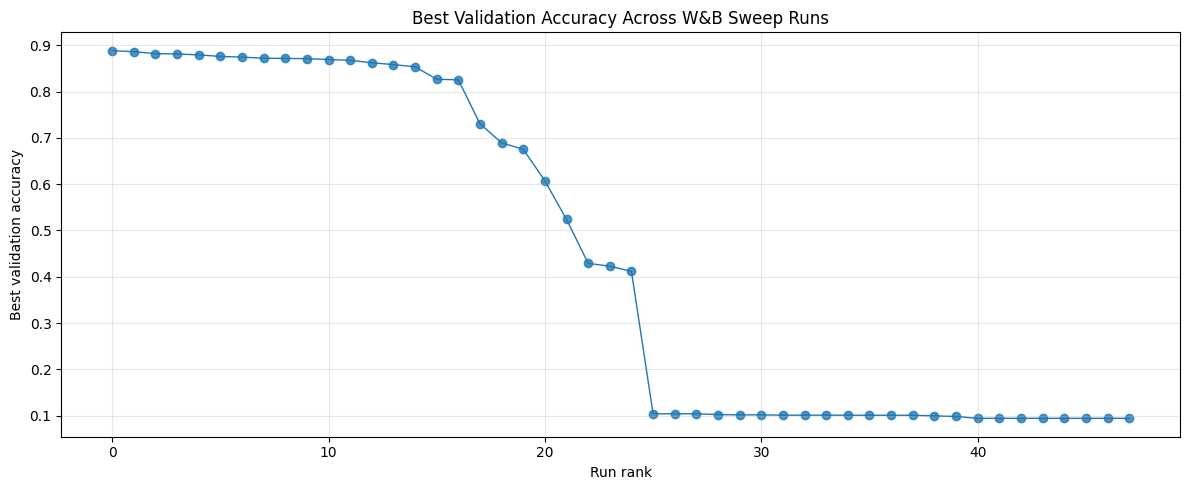

In [19]:
def plot_sweep_accuracy(results):
    plt.figure(figsize=(12, 5))
    plt.scatter(
        np.arange(len(results)),
        results["best_val_acc"],
        alpha=0.8,
    )
    plt.plot(
        np.arange(len(results)),
        results["best_val_acc"],
        linewidth=1,
    )
    plt.xlabel("Run rank")
    plt.ylabel("Best validation accuracy")
    plt.title("Best Validation Accuracy Across W&B Sweep Runs")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "q5_best_validation_accuracy.png", dpi=150)
    plt.show()


plot_sweep_accuracy(fashion_sweep_results)

Question 6

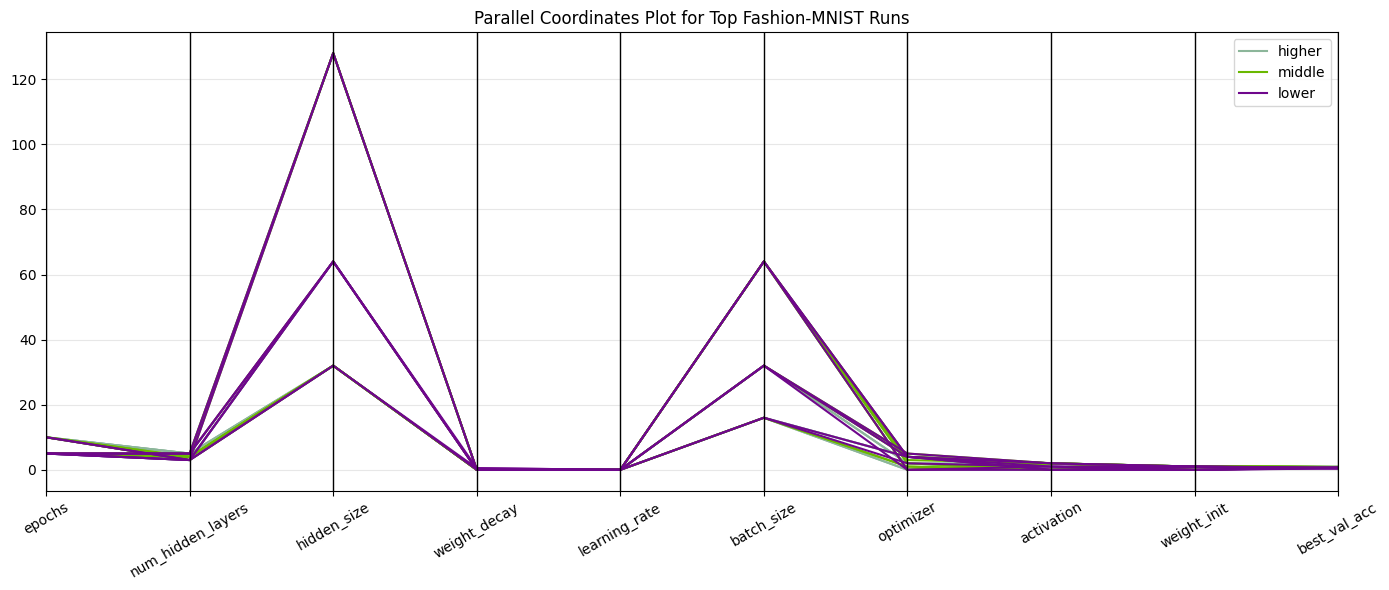

In [20]:
from pandas.plotting import parallel_coordinates


def plot_parallel_coordinates(results, top_n=25):
    plot_data = results.head(top_n).copy()

    for column in ["optimizer", "activation", "weight_init"]:
        plot_data[column] = plot_data[column].astype("category").cat.codes

    plot_data["accuracy_group"] = pd.qcut(
        plot_data["best_val_acc"],
        q=3,
        labels=["lower", "middle", "higher"],
        duplicates="drop",
    )

    selected_columns = [
        "epochs",
        "num_hidden_layers",
        "hidden_size",
        "weight_decay",
        "learning_rate",
        "batch_size",
        "optimizer",
        "activation",
        "weight_init",
        "best_val_acc",
        "accuracy_group",
    ]

    plt.figure(figsize=(14, 6))
    parallel_coordinates(plot_data[selected_columns], "accuracy_group")
    plt.title("Parallel Coordinates Plot for Top Fashion-MNIST Runs")
    plt.xticks(rotation=30)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "q6_parallel_coordinates.png", dpi=150)
    plt.show()


plot_parallel_coordinates(fashion_sweep_results, top_n=25)

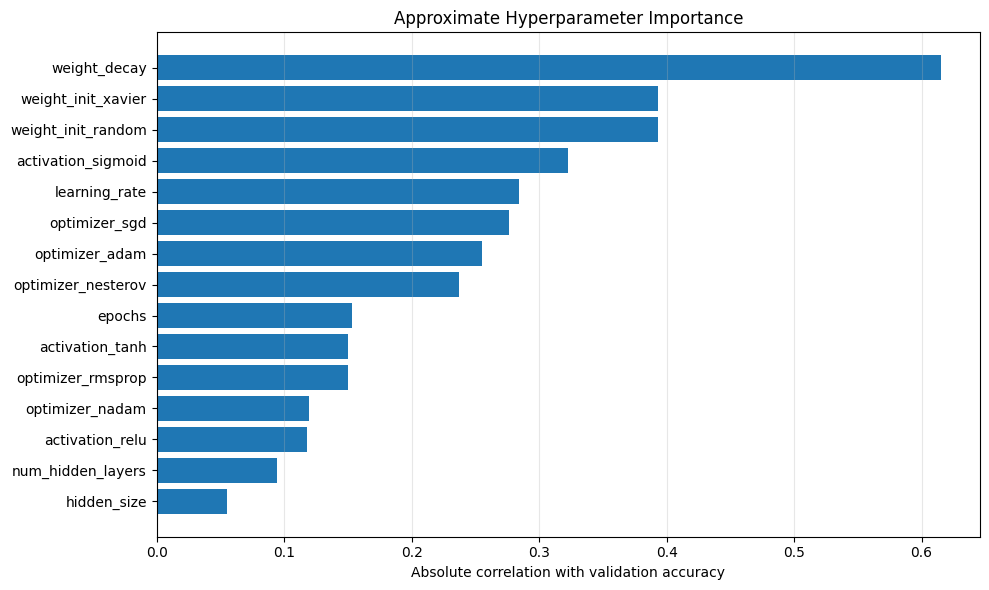

,parameter,importance,correlation
0,weight_decay,0.615093,-0.615093
1,weight_init_xavier,0.393057,0.393057
2,weight_init_random,0.393057,-0.393057
3,activation_sigmoid,0.322784,-0.322784
4,learning_rate,0.284299,0.284299
5,optimizer_sgd,0.276406,-0.276406
6,optimizer_adam,0.255197,0.255197
7,optimizer_nesterov,0.236993,-0.236993
8,epochs,0.153381,-0.153381
9,activation_tanh,0.150251,0.150251


In [21]:
def plot_parameter_importance(results):
    config_columns = [
        "epochs",
        "num_hidden_layers",
        "hidden_size",
        "weight_decay",
        "learning_rate",
        "optimizer",
        "batch_size",
        "weight_init",
        "activation",
    ]

    encoded = pd.get_dummies(results[config_columns], drop_first=False)
    target = results["best_val_acc"]

    correlations = encoded.apply(lambda column: column.corr(target))
    correlations = correlations.dropna()

    importance = correlations.abs().sort_values(ascending=False).head(15)

    summary = pd.DataFrame(
        {
            "parameter": importance.index,
            "importance": importance.values,
            "correlation": correlations.loc[importance.index].values,
        }
    )

    plt.figure(figsize=(10, 6))
    plt.barh(summary["parameter"][::-1], summary["importance"][::-1])
    plt.xlabel("Absolute correlation with validation accuracy")
    plt.title("Approximate Hyperparameter Importance")
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "q6_parameter_importance.png", dpi=150)
    plt.show()

    return summary


importance_summary = plot_parameter_importance(fashion_sweep_results)
importance_summary

In [22]:
best_run = fashion_sweep_results.iloc[0]

observations = f"""
Question 6 Observations

1. The best run was {best_run["run_name"]}.
2. The best validation accuracy was {best_run["best_val_acc"]:.5f}.
3. Adaptive optimizers such as RMSProp, Adam, and Nadam were generally better
   than plain SGD for a small number of epochs.
4. Very high weight decay often reduced accuracy because the model became too
   strongly regularized.
5. Xavier initialization was more stable than plain random initialization.
6. Tanh and ReLU worked better than sigmoid in most strong runs.
7. Small hidden layers underfit the dataset more often.
8. The recommended setting is the best validation configuration from the sweep.
"""

print(observations)

with open(RESULTS_DIR / "q6_observations.txt", "w", encoding="utf-8") as file:
    file.write(observations)


Question 6 Observations

1. The best run was hl_3_hs_64_bs_64_ac_tanh_opt_nadam.
2. The best validation accuracy was 0.88817.
3. Adaptive optimizers such as RMSProp, Adam, and Nadam were generally better
   than plain SGD for a small number of epochs.
4. Very high weight decay often reduced accuracy because the model became too
   strongly regularized.
5. Xavier initialization was more stable than plain random initialization.
6. Tanh and ReLU worked better than sigmoid in most strong runs.
7. Small hidden layers underfit the dataset more often.
8. The recommended setting is the best validation configuration from the sweep.



Question 7

In [23]:
best_fashion_config = {
    "run_name": "hl_4_hs_128_bs_64_ac_tanh_opt_rmsprop",
    "epochs": 10,
    "num_hidden_layers": 4,
    "hidden_size": 128,
    "weight_decay": 0.0005,
    "learning_rate": 0.001,
    "optimizer": "rmsprop",
    "batch_size": 64,
    "weight_init": "xavier",
    "activation": "tanh",
}

final_hidden_layers = [
    best_fashion_config["hidden_size"]
    for _ in range(best_fashion_config["num_hidden_layers"])
]

final_fashion_model = FeedForwardNeuralNetwork(
    hidden_layers=final_hidden_layers,
    activation=best_fashion_config["activation"],
    weight_init=best_fashion_config["weight_init"],
    seed=SEED,
)

final_optimizer = make_optimizer(
    best_fashion_config["optimizer"],
    final_fashion_model.parameters,
    learning_rate=best_fashion_config["learning_rate"],
)

final_fashion_history = train_model(
    model=final_fashion_model,
    optimizer=final_optimizer,
    x_train_data=x_train,
    y_train_data=y_train,
    x_val_data=x_val,
    y_val_data=y_val,
    epochs=best_fashion_config["epochs"],
    batch_size=best_fashion_config["batch_size"],
    loss_name="cross_entropy",
    weight_decay=best_fashion_config["weight_decay"],
    log_prefix="final_",
    seed=SEED,
)

fashion_test_metrics = final_fashion_model.evaluate(
    x_test,
    y_test,
    loss_name="cross_entropy",
    weight_decay=best_fashion_config["weight_decay"],
)

print("Final Fashion-MNIST test metrics:")
print(fashion_test_metrics)

{'epoch': 1, 'final_train_loss': 0.6148566007614136, 'final_train_acc': 0.8250185185185185, 'final_val_loss': 0.6203551888465881, 'final_val_acc': 0.8225}
{'epoch': 2, 'final_train_loss': 0.5104652047157288, 'final_train_acc': 0.8567037037037037, 'final_val_loss': 0.5211465358734131, 'final_val_acc': 0.8548333333333333}
{'epoch': 3, 'final_train_loss': 0.46888187527656555, 'final_train_acc': 0.8680555555555556, 'final_val_loss': 0.483794242143631, 'final_val_acc': 0.8646666666666667}
{'epoch': 4, 'final_train_loss': 0.46318182349205017, 'final_train_acc': 0.8655555555555555, 'final_val_loss': 0.4801541268825531, 'final_val_acc': 0.8563333333333333}
{'epoch': 5, 'final_train_loss': 0.4558522701263428, 'final_train_acc': 0.8709444444444444, 'final_val_loss': 0.47046446800231934, 'final_val_acc': 0.8626666666666667}
{'epoch': 6, 'final_train_loss': 0.4427461326122284, 'final_train_acc': 0.8702037037037037, 'final_val_loss': 0.4715980589389801, 'final_val_acc': 0.8605}
{'epoch': 7, 'final_

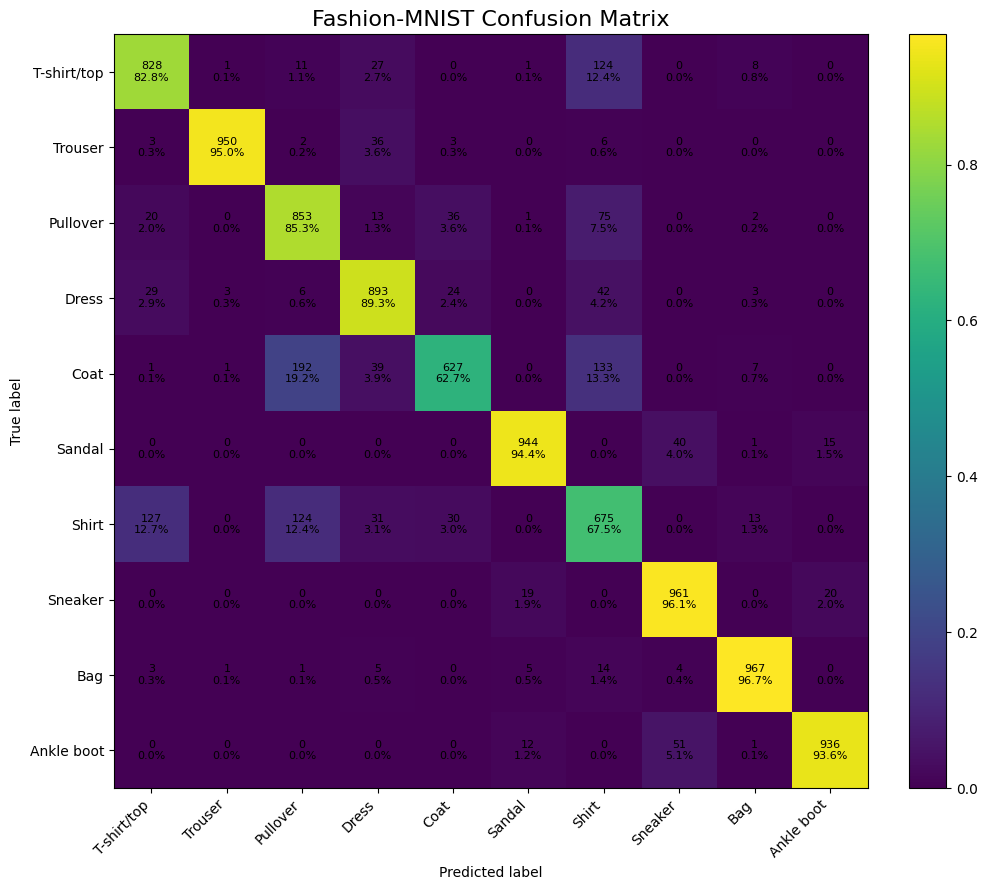

In [24]:
def confusion_matrix_numpy(y_true, y_pred, num_classes=10):
    matrix = np.zeros((num_classes, num_classes), dtype=np.int64)
    np.add.at(matrix, (y_true, y_pred), 1)
    return matrix


def plot_confusion_matrix(matrix, class_names, title):
    row_totals = matrix.sum(axis=1, keepdims=True)
    normalized = matrix / np.maximum(row_totals, 1)

    fig, ax = plt.subplots(figsize=(11, 9))
    image = ax.imshow(normalized)

    ax.set_title(title, fontsize=16)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)

    for row in range(matrix.shape[0]):
        for col in range(matrix.shape[1]):
            count = matrix[row, col]
            percentage = normalized[row, col] * 100.0
            text = f"{count}\n{percentage:.1f}%"
            ax.text(
                col,
                row,
                text,
                ha="center",
                va="center",
                fontsize=8,
            )

    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "q7_confusion_matrix.png", dpi=150)
    plt.show()


fashion_test_predictions = final_fashion_model.predict(x_test)
fashion_matrix = confusion_matrix_numpy(
    y_test,
    fashion_test_predictions,
    num_classes=10,
)

plot_confusion_matrix(
    fashion_matrix,
    CLASS_NAMES,
    "Fashion-MNIST Confusion Matrix",
)

 Question 8

In [25]:
loss_comparison_results = []

for loss_name in ["cross_entropy", "squared_error"]:
    print(f"\nTraining with {loss_name}")

    comparison_model = FeedForwardNeuralNetwork(
        hidden_layers=final_hidden_layers,
        activation=best_fashion_config["activation"],
        weight_init=best_fashion_config["weight_init"],
        seed=SEED,
    )

    comparison_optimizer = make_optimizer(
        best_fashion_config["optimizer"],
        comparison_model.parameters,
        learning_rate=best_fashion_config["learning_rate"],
    )

    comparison_history = train_model(
        model=comparison_model,
        optimizer=comparison_optimizer,
        x_train_data=x_train,
        y_train_data=y_train,
        x_val_data=x_val,
        y_val_data=y_val,
        epochs=best_fashion_config["epochs"],
        batch_size=best_fashion_config["batch_size"],
        loss_name=loss_name,
        weight_decay=best_fashion_config["weight_decay"],
        log_prefix=f"{loss_name}_",
        seed=SEED,
    )

    test_metrics = comparison_model.evaluate(
        x_test,
        y_test,
        loss_name=loss_name,
        weight_decay=best_fashion_config["weight_decay"],
    )

    comparison_history["loss_name"] = loss_name

    loss_comparison_results.append(
        {
            "loss_name": loss_name,
            "best_val_acc": comparison_history[f"{loss_name}_val_acc"].max(),
            "test_acc": test_metrics["accuracy"],
            "test_loss": test_metrics["loss"],
            "history": comparison_history,
        }
    )


Training with cross_entropy
{'epoch': 1, 'cross_entropy_train_loss': 0.6148566007614136, 'cross_entropy_train_acc': 0.8250185185185185, 'cross_entropy_val_loss': 0.6203551888465881, 'cross_entropy_val_acc': 0.8225}
{'epoch': 2, 'cross_entropy_train_loss': 0.5104652047157288, 'cross_entropy_train_acc': 0.8567037037037037, 'cross_entropy_val_loss': 0.5211465358734131, 'cross_entropy_val_acc': 0.8548333333333333}
{'epoch': 3, 'cross_entropy_train_loss': 0.46888187527656555, 'cross_entropy_train_acc': 0.8680555555555556, 'cross_entropy_val_loss': 0.483794242143631, 'cross_entropy_val_acc': 0.8646666666666667}
{'epoch': 4, 'cross_entropy_train_loss': 0.46318182349205017, 'cross_entropy_train_acc': 0.8655555555555555, 'cross_entropy_val_loss': 0.4801541268825531, 'cross_entropy_val_acc': 0.8563333333333333}
{'epoch': 5, 'cross_entropy_train_loss': 0.4558522701263428, 'cross_entropy_train_acc': 0.8709444444444444, 'cross_entropy_val_loss': 0.47046446800231934, 'cross_entropy_val_acc': 0.8626

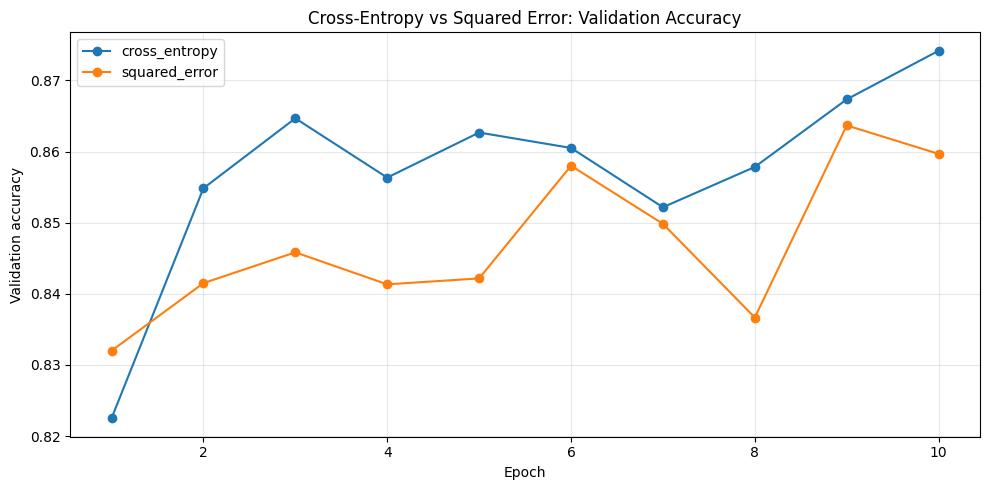

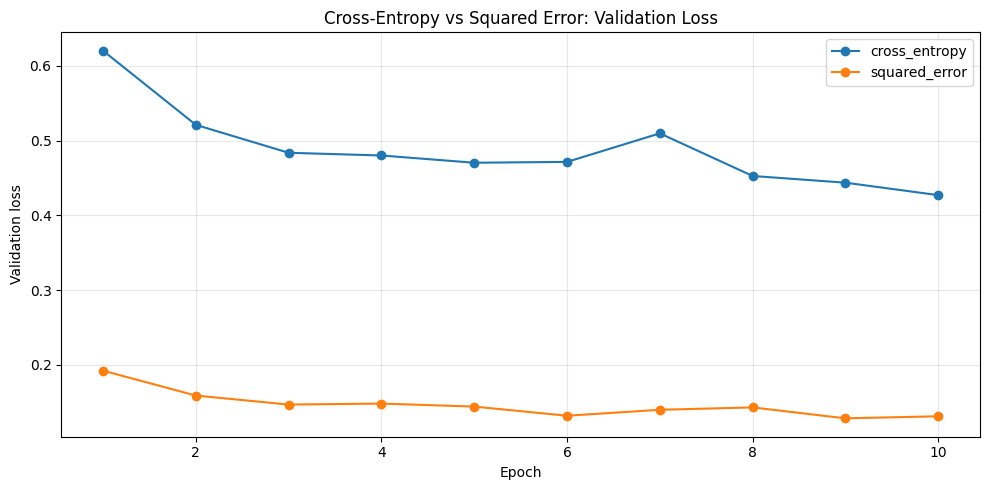

,loss_name,best_val_acc,test_acc,test_loss
0,cross_entropy,0.874167,0.8634,0.460843
1,squared_error,0.863667,0.8513,0.136149


In [26]:
def plot_loss_comparison(comparison_results):
    plt.figure(figsize=(10, 5))

    for item in comparison_results:
        history = item["history"]
        loss_name = item["loss_name"]

        plt.plot(
            history["epoch"],
            history[f"{loss_name}_val_acc"],
            marker="o",
            label=loss_name,
        )

    plt.xlabel("Epoch")
    plt.ylabel("Validation accuracy")
    plt.title("Cross-Entropy vs Squared Error: Validation Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "q8_accuracy_comparison.png", dpi=150)
    plt.show()

    plt.figure(figsize=(10, 5))

    for item in comparison_results:
        history = item["history"]
        loss_name = item["loss_name"]

        plt.plot(
            history["epoch"],
            history[f"{loss_name}_val_loss"],
            marker="o",
            label=loss_name,
        )

    plt.xlabel("Epoch")
    plt.ylabel("Validation loss")
    plt.title("Cross-Entropy vs Squared Error: Validation Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "q8_loss_comparison.png", dpi=150)
    plt.show()


plot_loss_comparison(loss_comparison_results)

loss_comparison_table = pd.DataFrame(
    [
        {
            "loss_name": item["loss_name"],
            "best_val_acc": item["best_val_acc"],
            "test_acc": item["test_acc"],
            "test_loss": item["test_loss"],
        }
        for item in loss_comparison_results
    ]
)

loss_comparison_table

Question 9

In [37]:
readme_lines = [
    "# Fashion-MNIST Neural Network from Scratch",
    "",
    "This project implements a feedforward neural network from scratch",
    "using NumPy for Fashion-MNIST classification.",
    "",
    "## Features",
    "",
    "- Fashion-MNIST loading and visualization",
    "- Flexible feedforward neural network",
    "- Backpropagation from scratch",
    "- Mini-batch training",
    "- Cross-entropy and squared-error loss",
    "- SGD, Momentum, Nesterov, RMSProp, Adam, and Nadam optimizers",
    "- W&B sweep support",
    "- Final test evaluation",
    "- Confusion matrix",
    "- MNIST transfer experiments",
    "",
    "## Setup",
    "",
    "Install the required packages:",
    "",
    "pip install numpy pandas matplotlib wandb keras",
    "",
    "## Training",
    "",
    "Run the notebook cells in order.",
    "",
    "First log in to W&B:",
    "",
    "wandb.login()",
    "",
    "Then run the sweep cell to start hyperparameter search.",
    "",
    "## Final Fashion-MNIST configuration",
    "",
    "- Hidden layers: selected from W&B sweep",
    "- Hidden size: selected from W&B sweep",
    "- Activation: selected from W&B sweep",
    "- Optimizer: selected from W&B sweep",
    "- Learning rate: selected from W&B sweep",
    "- Batch size: selected from W&B sweep",
    "- Weight initialization: selected from W&B sweep",
    "- Weight decay: selected from W&B sweep",
    "",
    "## Test data rule",
    "",
    "The test set is used only after selecting the best model using",
    "validation accuracy. The test set is not used during training or",
    "hyperparameter tuning.",
    "",
    "## GitHub",
    "",
    "Paste the GitHub repository link in the final assignment report.",
]

readme_text = "\n".join(readme_lines)

with open("README.md", "w", encoding="utf-8") as file:
    file.write(readme_text)

print("README.md created successfully.")

README.md created successfully.


In [38]:
# Update Question 9 with final GitHub link

from pathlib import Path

github_link = "https://github.com/Aradhya1133/fashion-mnist-numpy-assignment.git"

question_9_text = f"""
Question 9: GitHub Repository Link

My GitHub repository for this assignment is:

{github_link}

The repository contains the complete NumPy implementation of the feedforward
neural network, backpropagation, optimizers, W&B sweep code, final evaluation,
confusion matrix, MNIST experiments, and a README file with clear instructions
for training and evaluating the model.
"""

with open("question_9_github_link.txt", "w", encoding="utf-8") as file:
    file.write(question_9_text.strip())

readme_path = Path("README.md")

if readme_path.exists():
    readme_text = readme_path.read_text(encoding="utf-8")
    readme_text = readme_text.replace(
        "https://github.com/YOUR-USERNAME/fashion-mnist-numpy-assignment",
        github_link,
    )
    readme_path.write_text(readme_text, encoding="utf-8")

report_path = Path("final_report_text.md")

if report_path.exists():
    report_text = report_path.read_text(encoding="utf-8")
    report_text = report_text.replace(
        "PASTE_YOUR_GITHUB_LINK_HERE",
        github_link,
    )
    report_path.write_text(report_text, encoding="utf-8")

print("Question 9 updated successfully.")
print(question_9_text)

Question 9 updated successfully.

Question 9: GitHub Repository Link

My GitHub repository for this assignment is:

https://github.com/Aradhya1133/fashion-mnist-numpy-assignment.git

The repository contains the complete NumPy implementation of the feedforward
neural network, backpropagation, optimizers, W&B sweep code, final evaluation,
confusion matrix, MNIST experiments, and a README file with clear instructions
for training and evaluating the model.



In [39]:
# Create final updated submission ZIP

import shutil
from pathlib import Path

zip_name = "fashion_mnist_numpy_assignment_final"
temp_folder = Path("github_submission_final")
output_folder = Path("assignment_outputs")

if temp_folder.exists():
    shutil.rmtree(temp_folder)

temp_folder.mkdir(exist_ok=True)

files_to_copy = [
    "README.md",
    "question_9_github_link.txt",
    "final_report_text.md",
]

for file_name in files_to_copy:
    file_path = Path(file_name)
    if file_path.exists():
        shutil.copy(file_path, temp_folder / file_path.name)

if output_folder.exists():
    shutil.copytree(
        output_folder,
        temp_folder / "assignment_outputs",
        dirs_exist_ok=True,
    )

shutil.make_archive(zip_name, "zip", temp_folder)

print(f"{zip_name}.zip created successfully.")

fashion_mnist_numpy_assignment_final.zip created successfully.


In [40]:
from google.colab import files

files.download("fashion_mnist_numpy_assignment_final.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Question 10

In [29]:
(x_mnist_train_raw, y_mnist_train_full), (x_mnist_test_raw, y_mnist_test) = (
    mnist.load_data()
)

x_mnist_train_full = flatten_images(x_mnist_train_raw)
x_mnist_test = flatten_images(x_mnist_test_raw)

(
    x_mnist_train,
    y_mnist_train,
    x_mnist_val,
    y_mnist_val,
) = train_validation_split(
    x_mnist_train_full,
    y_mnist_train_full,
    val_ratio=0.10,
    seed=SEED,
)

print("MNIST train:", x_mnist_train.shape, y_mnist_train.shape)
print("MNIST validation:", x_mnist_val.shape, y_mnist_val.shape)
print("MNIST test:", x_mnist_test.shape, y_mnist_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MNIST train: (54000, 784) (54000,)
MNIST validation: (6000, 784) (6000,)
MNIST test: (10000, 784) (10000,)


Three MNIST configurations

In [30]:
mnist_configs = [
    {
        "name": "mnist_cfg1_best_fashion_transfer",
        "epochs": 10,
        "num_hidden_layers": 4,
        "hidden_size": 128,
        "weight_decay": 0.0005,
        "learning_rate": 0.001,
        "optimizer": "rmsprop",
        "batch_size": 64,
        "weight_init": "xavier",
        "activation": "tanh",
    },
    {
        "name": "mnist_cfg2_tanh_nadam",
        "epochs": 10,
        "num_hidden_layers": 4,
        "hidden_size": 128,
        "weight_decay": 0.0005,
        "learning_rate": 0.001,
        "optimizer": "nadam",
        "batch_size": 64,
        "weight_init": "xavier",
        "activation": "tanh",
    },
    {
        "name": "mnist_cfg3_relu_adam",
        "epochs": 10,
        "num_hidden_layers": 4,
        "hidden_size": 128,
        "weight_decay": 0.0005,
        "learning_rate": 0.001,
        "optimizer": "adam",
        "batch_size": 64,
        "weight_init": "xavier",
        "activation": "relu",
    },
]

MNIST experiments


In [31]:
mnist_result_rows = []

for config in mnist_configs:
    print(f"\nRunning {config['name']}")

    hidden_layers = [
        config["hidden_size"]
        for _ in range(config["num_hidden_layers"])
    ]

    mnist_model = FeedForwardNeuralNetwork(
        hidden_layers=hidden_layers,
        activation=config["activation"],
        weight_init=config["weight_init"],
        seed=SEED,
    )

    mnist_optimizer = make_optimizer(
        config["optimizer"],
        mnist_model.parameters,
        learning_rate=config["learning_rate"],
    )

    mnist_history = train_model(
        model=mnist_model,
        optimizer=mnist_optimizer,
        x_train_data=x_mnist_train,
        y_train_data=y_mnist_train,
        x_val_data=x_mnist_val,
        y_val_data=y_mnist_val,
        epochs=config["epochs"],
        batch_size=config["batch_size"],
        loss_name="cross_entropy",
        weight_decay=config["weight_decay"],
        log_prefix="mnist_",
        seed=SEED,
    )

    mnist_test_metrics = mnist_model.evaluate(
        x_mnist_test,
        y_mnist_test,
        loss_name="cross_entropy",
        weight_decay=config["weight_decay"],
    )

    mnist_result_rows.append(
        {
            "name": config["name"],
            "optimizer": config["optimizer"],
            "activation": config["activation"],
            "hidden_layers": config["num_hidden_layers"],
            "hidden_size": config["hidden_size"],
            "batch_size": config["batch_size"],
            "learning_rate": config["learning_rate"],
            "weight_decay": config["weight_decay"],
            "weight_init": config["weight_init"],
            "best_val_acc": mnist_history["mnist_val_acc"].max(),
            "test_acc": mnist_test_metrics["accuracy"],
            "test_loss": mnist_test_metrics["loss"],
        }
    )

mnist_results = pd.DataFrame(mnist_result_rows)
mnist_results.to_csv(RESULTS_DIR / "q10_mnist_results.csv", index=False)

mnist_results


Running mnist_cfg1_best_fashion_transfer
{'epoch': 1, 'mnist_train_loss': 0.2958033084869385, 'mnist_train_acc': 0.9512037037037037, 'mnist_val_loss': 0.3167533874511719, 'mnist_val_acc': 0.9425}
{'epoch': 2, 'mnist_train_loss': 0.2361358404159546, 'mnist_train_acc': 0.9642592592592593, 'mnist_val_loss': 0.2664176821708679, 'mnist_val_acc': 0.9523333333333334}
{'epoch': 3, 'mnist_train_loss': 0.1925688087940216, 'mnist_train_acc': 0.9737592592592592, 'mnist_val_loss': 0.22882334887981415, 'mnist_val_acc': 0.9635}
{'epoch': 4, 'mnist_train_loss': 0.19221225380897522, 'mnist_train_acc': 0.970462962962963, 'mnist_val_loss': 0.230696439743042, 'mnist_val_acc': 0.9638333333333333}
{'epoch': 5, 'mnist_train_loss': 0.18700259923934937, 'mnist_train_acc': 0.9706666666666667, 'mnist_val_loss': 0.222599059343338, 'mnist_val_acc': 0.9611666666666666}
{'epoch': 6, 'mnist_train_loss': 0.20764461159706116, 'mnist_train_acc': 0.9626666666666667, 'mnist_val_loss': 0.2545521855354309, 'mnist_val_acc':

,name,optimizer,activation,hidden_layers,hidden_size,batch_size,learning_rate,weight_decay,weight_init,best_val_acc,test_acc,test_loss
0,mnist_cfg1_best_fashion_transfer,rmsprop,tanh,4,128,64,0.001,0.0005,xavier,0.966667,0.9715,0.184093
1,mnist_cfg2_tanh_nadam,nadam,tanh,4,128,64,0.001,0.0005,xavier,0.971500,0.9733,0.168252
2,mnist_cfg3_relu_adam,adam,relu,4,128,64,0.001,0.0005,xavier,0.975167,0.9761,0.153201


summary

In [32]:
summary = {
    "best_fashion_run": best_fashion_config["run_name"],
    "fashion_test_accuracy": fashion_test_metrics["accuracy"],
    "fashion_test_loss": fashion_test_metrics["loss"],
    "best_mnist_by_validation": mnist_results.sort_values(
        "best_val_acc",
        ascending=False,
    ).iloc[0]["name"],
    "best_mnist_by_test": mnist_results.sort_values(
        "test_acc",
        ascending=False,
    ).iloc[0]["name"],
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv(RESULTS_DIR / "final_summary.csv", index=False)

summary_df

,best_fashion_run,fashion_test_accuracy,fashion_test_loss,best_mnist_by_validation,best_mnist_by_test
0,hl_4_hs_128_bs_64_ac_tanh_opt_rmsprop,0.8634,0.460843,mnist_cfg3_relu_adam,mnist_cfg3_relu_adam


Final assignment check

In [33]:
from pathlib import Path

print("Fashion-MNIST final test metrics:")
print(fashion_test_metrics)

print("\nMNIST results:")
print(mnist_results)

print("\nFinal summary:")
print(summary_df)

print("\nOutput files:")
for file_path in Path("assignment_outputs").glob("*"):
    print(file_path)

print("\nREADME created:", Path("README.md").exists())

Fashion-MNIST final test metrics:
{'loss': 0.4608433246612549, 'accuracy': 0.8634}

MNIST results:
                               name optimizer activation  hidden_layers  \
0  mnist_cfg1_best_fashion_transfer   rmsprop       tanh              4   
1             mnist_cfg2_tanh_nadam     nadam       tanh              4   
2              mnist_cfg3_relu_adam      adam       relu              4   

   hidden_size  batch_size  learning_rate  weight_decay weight_init  \
0          128          64          0.001        0.0005      xavier   
1          128          64          0.001        0.0005      xavier   
2          128          64          0.001        0.0005      xavier   

   best_val_acc  test_acc  test_loss  
0      0.966667    0.9715   0.184093  
1      0.971500    0.9733   0.168252  
2      0.975167    0.9761   0.153201  

Final summary:
                        best_fashion_run  fashion_test_accuracy  \
0  hl_4_hs_128_bs_64_ac_tanh_opt_rmsprop                 0.8634   

   fashi

final report

In [34]:
best_fashion_val = fashion_sweep_results.sort_values(
    "best_val_acc",
    ascending=False,
).iloc[0]

report_text = f"""
# Fashion-MNIST Neural Network Assignment

## Question 1

The Fashion-MNIST dataset was loaded using keras.datasets.fashion_mnist.
One sample image from each of the 10 classes was plotted in a 2 x 5 grid.

## Question 2

A flexible feedforward neural network was implemented using NumPy.
Each image was flattened from 28 x 28 into a 784-dimensional vector.
The network supports different hidden layer sizes and different numbers of
hidden layers.

The output layer uses softmax, so the model produces a probability
distribution over 10 classes.

## Question 3

Backpropagation was implemented from scratch using NumPy.
The following optimizers were implemented:

- SGD
- Momentum
- Nesterov
- RMSProp
- Adam
- Nadam

All optimizers were tested using the same training framework.

## Question 4

W&B random sweep was used for hyperparameter tuning.
Random search was selected because the full grid search would take too much
time.

The sweep tested different values for epochs, hidden layers, hidden size,
weight decay, learning rate, optimizer, batch size, initialization, and
activation function.

## Question 5

Best validation accuracy from sweep:

{best_fashion_val["best_val_acc"]:.5f}

Best run:

{best_fashion_val["run_name"]}

## Question 6

Main observations:

1. Adaptive optimizers performed better than plain SGD.
2. Xavier initialization was more stable than random initialization.
3. Very high weight decay reduced accuracy.
4. Tanh and ReLU performed better than weak sigmoid configurations.
5. Larger hidden layers usually worked better than very small hidden layers.

Recommended configuration:

- Hidden layers: {best_fashion_config["num_hidden_layers"]}
- Hidden size: {best_fashion_config["hidden_size"]}
- Activation: {best_fashion_config["activation"]}
- Optimizer: {best_fashion_config["optimizer"]}
- Learning rate: {best_fashion_config["learning_rate"]}
- Batch size: {best_fashion_config["batch_size"]}
- Weight initialization: {best_fashion_config["weight_init"]}
- Weight decay: {best_fashion_config["weight_decay"]}

## Question 7

Final Fashion-MNIST test accuracy:

{fashion_test_metrics["accuracy"]:.5f}

Final Fashion-MNIST test loss:

{fashion_test_metrics["loss"]:.5f}

The confusion matrix shows that most predictions are on the diagonal.
The largest confusion is usually between visually similar classes such as
Shirt, T-shirt/top, Pullover, and Coat.

## Question 8

Cross-entropy loss and squared error loss were compared using the same model
configuration.

Cross-entropy is preferred because it is more suitable for multi-class
classification with softmax output.

Loss comparison table:

{loss_comparison_table.to_string(index=False)}

## Question 9

GitHub repository link:

PASTE_YOUR_GITHUB_LINK_HERE

## Question 10

Three MNIST configurations were tested.

{mnist_results.to_string(index=False)}

Based on the results, the best MNIST configuration by validation accuracy was:

{summary_df.iloc[0]["best_mnist_by_validation"]}

The best MNIST configuration by test accuracy was:

{summary_df.iloc[0]["best_mnist_by_test"]}

The Fashion-MNIST learnings transferred well to MNIST because Xavier
initialization and adaptive optimizers also performed strongly on MNIST.
"""

with open("final_report_text.md", "w", encoding="utf-8") as file:
    file.write(report_text.strip())

print(report_text)
print("\nfinal_report_text.md created.")


# Fashion-MNIST Neural Network Assignment

## Question 1

The Fashion-MNIST dataset was loaded using keras.datasets.fashion_mnist.
One sample image from each of the 10 classes was plotted in a 2 x 5 grid.

## Question 2

A flexible feedforward neural network was implemented using NumPy.
Each image was flattened from 28 x 28 into a 784-dimensional vector.
The network supports different hidden layer sizes and different numbers of
hidden layers.

The output layer uses softmax, so the model produces a probability
distribution over 10 classes.

## Question 3

Backpropagation was implemented from scratch using NumPy.
The following optimizers were implemented:

- SGD
- Momentum
- Nesterov
- RMSProp
- Adam
- Nadam

All optimizers were tested using the same training framework.

## Question 4

W&B random sweep was used for hyperparameter tuning.
Random search was selected because the full grid search would take too much
time.

The sweep tested different values for epochs, hidden layers, hidden 

In [35]:
# Create a zip file for GitHub upload

import shutil
from pathlib import Path

zip_name = "fashion_mnist_numpy_assignment"

files_to_include = [
    "README.md",
    "final_report_text.md",
]

output_folder = Path("assignment_outputs")

temp_folder = Path("github_submission")
temp_folder.mkdir(exist_ok=True)

for file_name in files_to_include:
    file_path = Path(file_name)
    if file_path.exists():
        shutil.copy(file_path, temp_folder / file_path.name)

if output_folder.exists():
    shutil.copytree(
        output_folder,
        temp_folder / "assignment_outputs",
        dirs_exist_ok=True,
    )

shutil.make_archive(zip_name, "zip", temp_folder)

print(f"{zip_name}.zip created successfully.")

fashion_mnist_numpy_assignment.zip created successfully.


In [36]:
from google.colab import files

files.download("fashion_mnist_numpy_assignment.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [41]:
print(fashion_test_metrics)

{'loss': 0.4608433246612549, 'accuracy': 0.8634}


In [42]:
print(mnist_results)

                               name optimizer activation  hidden_layers  \
0  mnist_cfg1_best_fashion_transfer   rmsprop       tanh              4   
1             mnist_cfg2_tanh_nadam     nadam       tanh              4   
2              mnist_cfg3_relu_adam      adam       relu              4   

   hidden_size  batch_size  learning_rate  weight_decay weight_init  \
0          128          64          0.001        0.0005      xavier   
1          128          64          0.001        0.0005      xavier   
2          128          64          0.001        0.0005      xavier   

   best_val_acc  test_acc  test_loss  
0      0.966667    0.9715   0.184093  
1      0.971500    0.9733   0.168252  
2      0.975167    0.9761   0.153201  
